In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer



df = pd.read_csv('train_data.csv')

df.shape

(1523975, 2)

In [ ]:
#0 -> negative 
#1 -> positive
df.head()


,sentence,sentiment
0,awww that s a bummer you shoulda got david car...,0
1,is upset that he can t update his facebook by ...,0
2,i dived many times for the ball managed to sav...,0
3,my whole body feels itchy and like its on fire,0
4,no it s not behaving at all i m mad why am i h...,0


In [3]:
df['sentiment'].value_counts()

sentiment
0    767059
1    756916
Name: count, dtype: int64

In [4]:
df.isnull().sum()

sentence     0
sentiment    0
dtype: int64

In [5]:
df['tweet_length'] = df['sentence'].str.len()
df.head()

,sentence,sentiment,tweet_length
0,awww that s a bummer you shoulda got david car...,0,71
1,is upset that he can t update his facebook by ...,0,105
2,i dived many times for the ball managed to sav...,0,73
3,my whole body feels itchy and like its on fire,0,46
4,no it s not behaving at all i m mad why am i h...,0,88


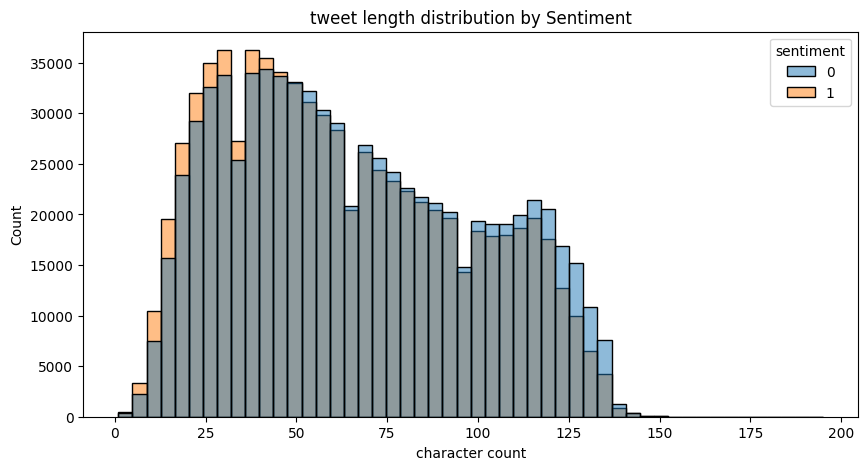

In [8]:
plt.figure(figsize=(10,5))
#hue tells to color the bars with column='sentiment'
#bins divides the x axis in some particular number of buckets
sns.histplot(data=df , x='tweet_length' , hue='sentiment' , bins=50)
plt.title('tweet length distribution by Sentiment')
plt.xlabel('character count')
plt.show()

In [ ]:
from collections import Counter

#all_words is like a list of all words used in tweets
all_words = ' '.join(df['sentence']).split()
#finding top 20 most commonly used words in the tweets
common_words = Counter(all_words).most_common(20)
#these are words that help us in no way to tell if a comment is positive or negative
print(common_words)

[('i', 942425), ('to', 557878), ('the', 516121), ('a', 376673), ('my', 312328), ('and', 301617), ('it', 301600), ('you', 288483), ('is', 233124), ('in', 214757), ('for', 212350), ('s', 186745), ('of', 182303), ('t', 181078), ('on', 165054), ('that', 162635), ('me', 158997), ('so', 150877), ('have', 143559), ('m', 136859)]


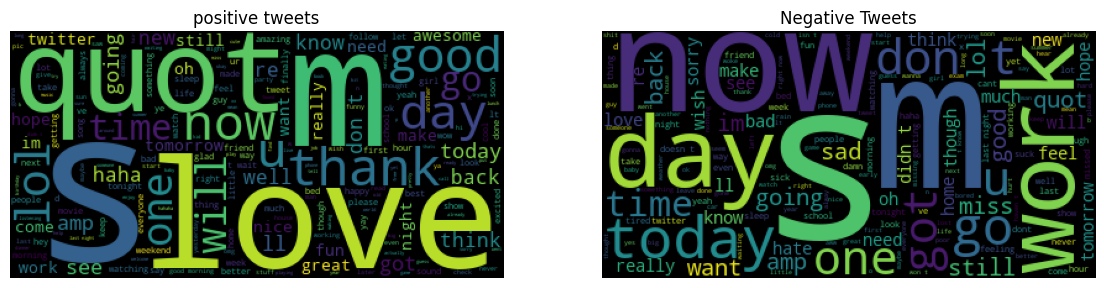

In [12]:
from wordcloud import WordCloud

positiveDF = df[df['sentiment'] == 1]['sentence'].sample(10000, random_state=42)
negativeDF = df[df['sentiment'] == 0]['sentence'].sample(10000, random_state=42)

positiveString = ' '.join(positiveDF)
negativeString = ' '.join(negativeDF)

plt.figure(figsize=(14,6))

plt.subplot(1 , 2 , 1)
wordcloud = WordCloud().generate(positiveString)
plt.imshow(wordcloud)
plt.axis('off')
plt.title('positive tweets')

plt.subplot(1 , 2, 2)

wordcloud = WordCloud().generate(negativeString)
plt.imshow(wordcloud)
plt.axis('off')
plt.title('Negative Tweets')

plt.show()

In [13]:
#regular expressions. helps in manipulation of patterns in text
import re
#natural language toolkit
import nltk
#stopwords -> common words like the , a that have no meaning
nltk.download('stopwords')

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

stop_words = set(stopwords.words('english'))

#stemmer will reduce words to their base form. Ex-> running will be reduced to run
stemmer = PorterStemmer()

[nltk_data] Downloading package stopwords to C:\Users\Rajeev
[nltk_data]     Kumar\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


In [18]:
def clean_tweet(text):

    text = text.lower()
    #(pattern , replacement , text)
    #meaning of r'http\S+: r''->treats backslashes literally , \S -> any non whitespace character , + means one or more of the previous thing
    #http\S+ means: "find http followed by one or more non-space characters
    text = re.sub(r'http\S+' , '' , text)
    text = re.sub(r'@\S+' , '' , text)
    text = re.sub(r'#' , '' , text)
    text = re.sub(r'&\S+;', '', text)
    text = re.sub(r'\d', '', text)
    text = re.sub(r'[^a-z\s]', '', text)

    words = text.split()
    words = [word for word in words if word not in stop_words]
    text = ' '.join(words)

    words = text.split()
    words = [stemmer.stem(word) for word in words]
    text = ' '.join(words)


    return text


df['cleaned'] = df['sentence'].apply(clean_tweet)

df[['sentence' , 'cleaned']].head(10)

,sentence,cleaned
0,awww that s a bummer you shoulda got david car...,awww bummer shoulda got david carr third day
1,is upset that he can t update his facebook by ...,upset updat facebook text might cri result sch...
2,i dived many times for the ball managed to sav...,dive mani time ball manag save rest go bound
3,my whole body feels itchy and like its on fire,whole bodi feel itchi like fire
4,no it s not behaving at all i m mad why am i h...,behav mad see
5,not the whole crew,whole crew
6,need a hug,need hug
7,hey long time no see yes rains a bit only a bi...,hey long time see ye rain bit bit lol fine thank
8,nope they didn t have it,nope
9,que me muera,que muera


TF-IDF

TF(term frequency) -> how often a word appears in a single tweet
        higher TF means that word is important in that tweet.

IDF(Inverse Document Frequency) -> how rare a word is across all tweets
    rare words get higher IDF

TF-IDF score = TF * IDF

In [ ]:

#after vectorization we get a matrix -> each row is our tweet
#each column is a word

#max_features = 50000 -> take only 50000 unique words as columns
#limiting the max_features so that our model doesn't overfit
tfidf = TfidfVectorizer(max_features=50000)

#X is our feature matrix
X = tfidf.fit_transform(df['cleaned'])
y = df['sentiment']

print(X.shape)

(1523975, 50000)


In [ ]:
#random_state = 42 is a convention so that the split is reproducible every time you run it

X_train , X_test , y_train , y_test = train_test_split(
    X , y , test_size=0.2 , random_state=42
)